In [1]:
# A Motivating Example: Linear Regression

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use('arviz-darkgrid')

In [4]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

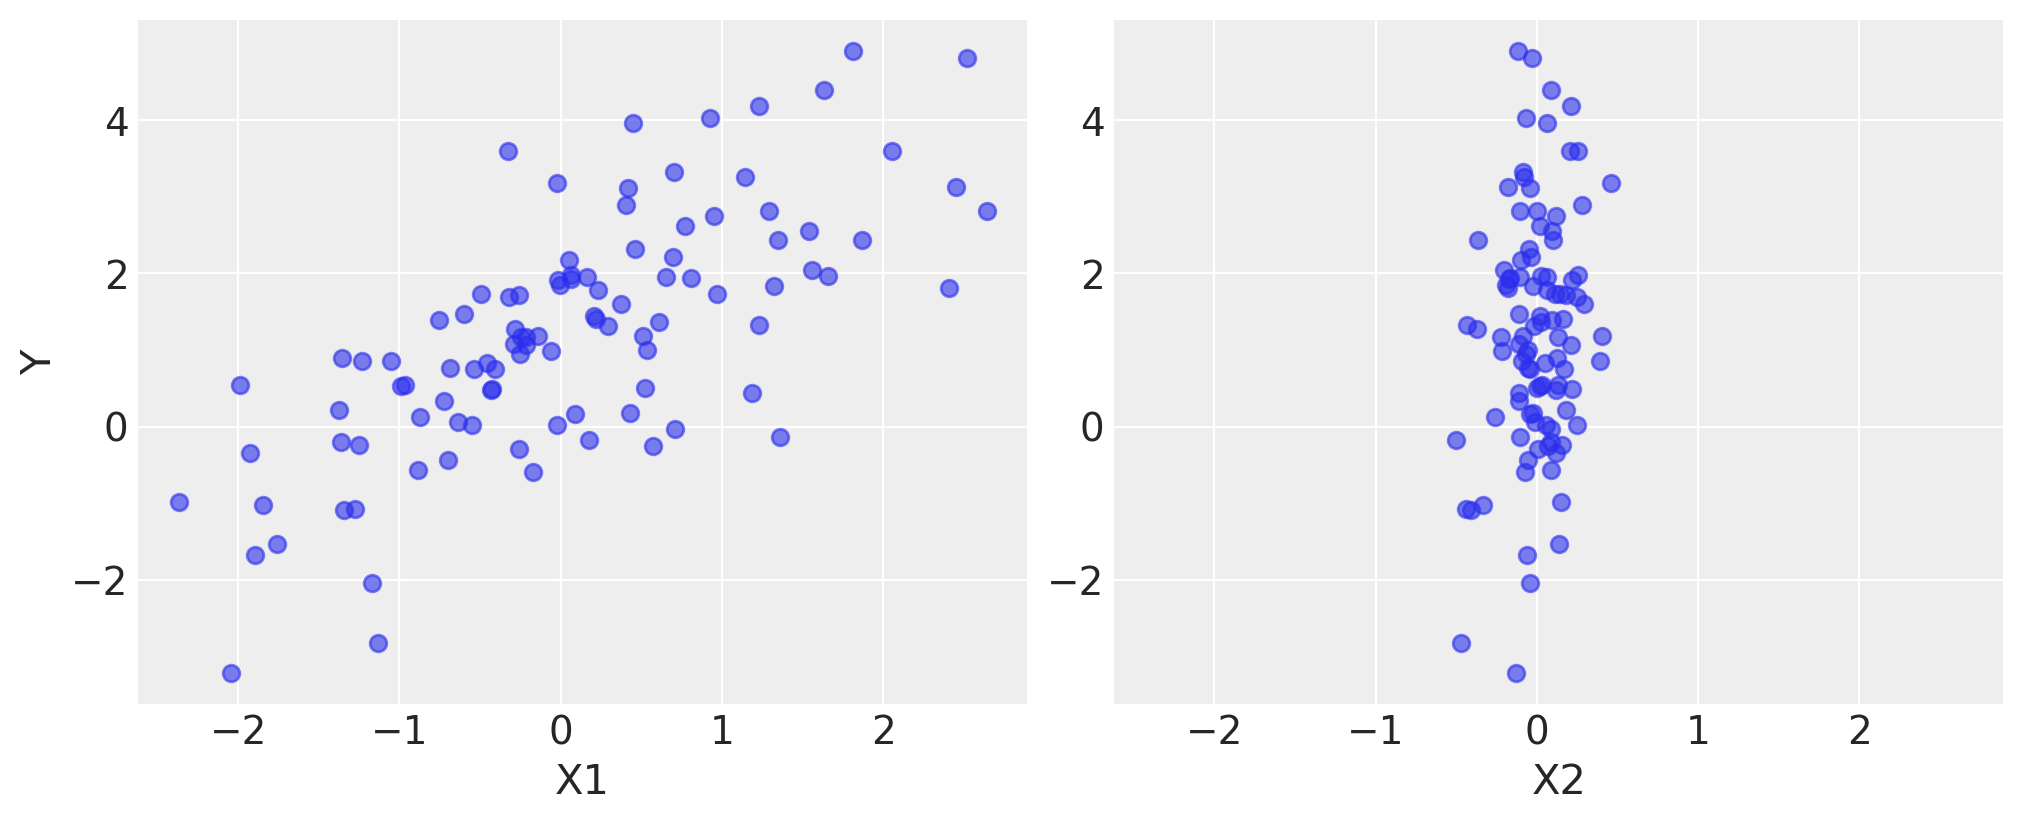

In [5]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2");

In [6]:
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.19.1


In [7]:
basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.Normal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

In [8]:
with basic_model:
    # draw 1000 posterior samples
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 66 seconds.


In [9]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [10]:
idata.posterior["alpha"].sel(draw=slice(0, 4))

<xarray.DataArray 'alpha' (chain: 4, draw: 5)> Size: 160B
array([[1.08993326, 1.22614917, 1.09344918, 1.11870771, 1.12516925],
       [1.06083834, 1.280336  , 1.09113622, 1.17947607, 1.10956395],
       [1.25945075, 1.03937675, 1.12991522, 1.22866573, 1.15352788],
       [0.97848873, 1.15361287, 1.13750814, 1.04889305, 1.02846346]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 40B 0 1 2 3 4

In [14]:
with basic_model:
    # instantiate sample
    #step = pm.Slice()
    step = pm.NUTS()

    # draw 5000 posterior samples
    slice_idata = pm.sample(5000, step=step, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

ParallelSamplingError: Chain 2 failed with: Bad initial energy: SamplerWarning(kind=<WarningType.BAD_ENERGY: 8>, message='Bad initial energy, check any log probabilities that are inf or -inf, nan or very small:\n[-inf]\n.Try model.debug() to identify parametrization problems.', level='critical', step=0, exec_info=None, extra=None, divergence_point_source=None, divergence_point_dest=None, divergence_info=None)

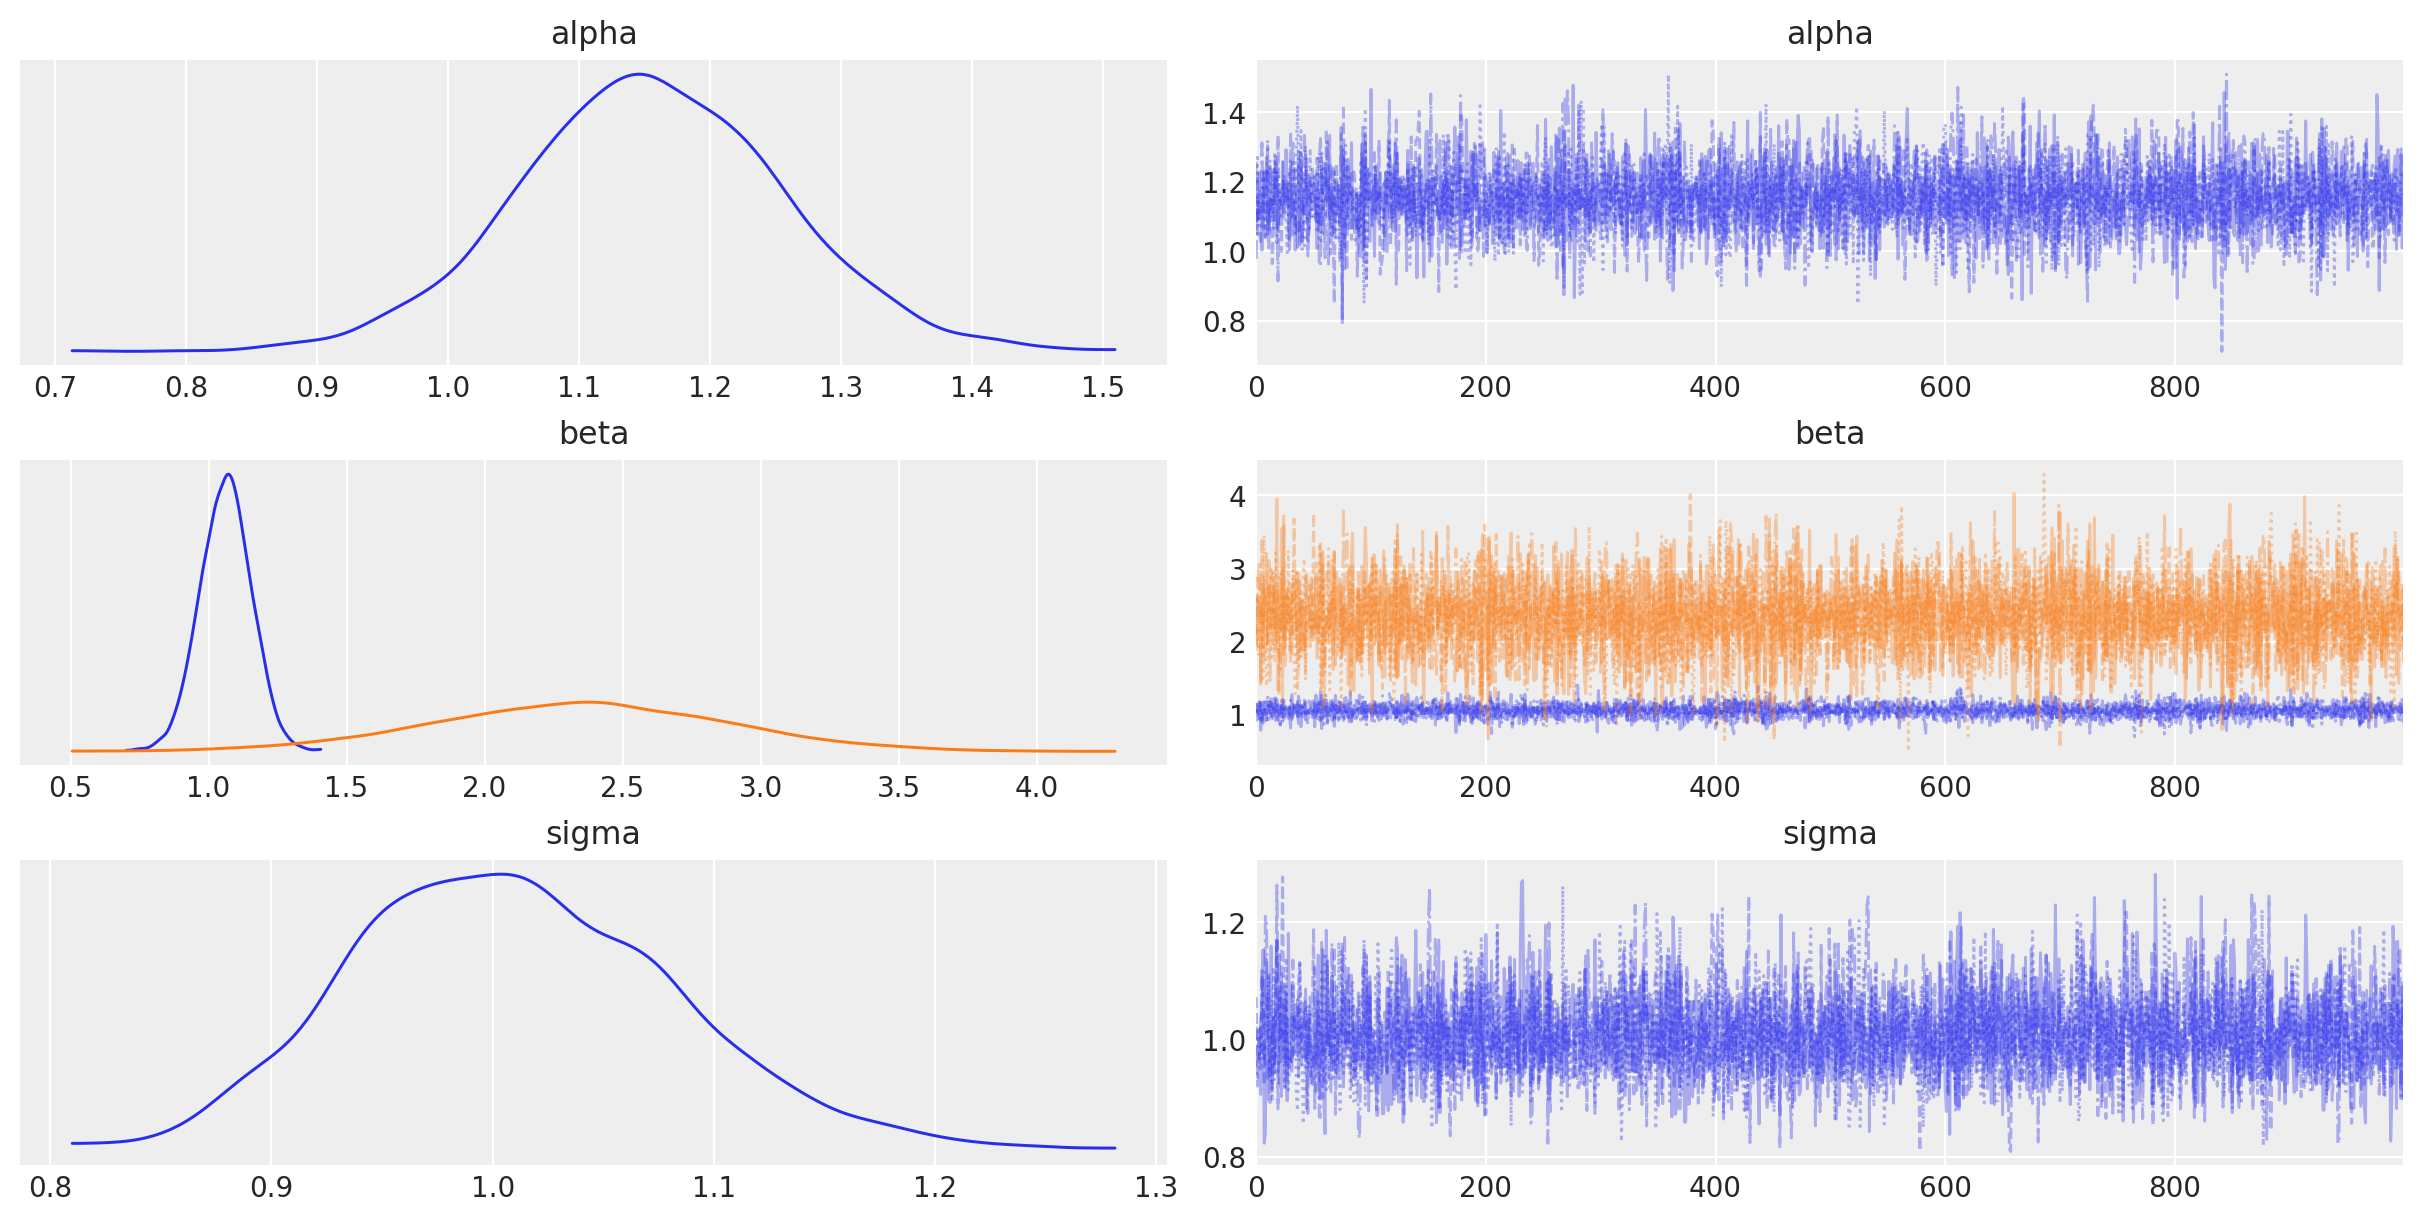

In [15]:
az.plot_trace(idata, combined=True);

In [16]:
az.summary(idata, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.15,0.10,0.97,1.35,0.00,0.0,5960.01,3040.27,1.0
beta[0],1.06,0.09,0.89,1.23,0.00,0.0,5739.30,3271.00,1.0
beta[1],2.34,0.53,1.31,3.31,0.01,0.0,6103.51,3418.13,1.0
sigma,1.01,0.07,0.88,1.15,0.00,0.0,5040.07,2784.39,1.0
